# Canada Coverage Analysis

End-to-end demonstration of **missiontools** coverage and plotting features.

**Scenario**
- Sun-synchronous orbit, 550 km, 10:30 LTAN (ascending)
- Nadir-pointed pushbroom sensor, 20° half-angle FOV
- Min ground elevation: 20°
- Illumination constraint: solar zenith angle < 70° (daytime)
- Area of interest: Canada (20 000 km² point density)
- Simulation window: 90 days

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from missiontools import Spacecraft, Sensor, AoI, Coverage
from missiontools.plotting import plot_ground_track, plot_coverage_map

## 1. Build the spacecraft

In [2]:
EPOCH = np.datetime64('2025-05-01T00:00:00', 'us')

sc = Spacecraft.sunsync(
    altitude_km=550.0,
    node_solar_time='10:30',
    epoch=EPOCH,
)

print(f"Semi-major axis : {sc.a/1e3:.1f} km")
print(f"Inclination     : {np.degrees(sc.i):.2f} deg")
print(f"RAAN            : {np.degrees(sc.raan):.2f} deg")
print(f"Propagator      : {sc.propagator_type}")

Semi-major axis : 6928.1 km
Inclination     : 97.59 deg
RAAN            : 15.96 deg
Propagator      : j2


## 2. Attach a nadir-pointed sensor

In [3]:
sensor = Sensor(half_angle_deg=20.0, body_vector=[0, 0, 1])
sc.add_sensor(sensor)

print(f"FOV half-angle  : {np.degrees(sensor.half_angle_rad):.1f}°")

FOV half-angle  : 20.0°


## 3. Define the Area of Interest

In [4]:
# 20 000 km² per sample point  (~141 km spacing)
aoi = AoI.from_geography('Canada', point_density=20_000)
print(f"AoI sample points: {len(aoi)}")

AoI sample points: 644


## 4. Set up Coverage analysis

In [5]:
cov = Coverage(
    aoi,
    [sensor],
    el_min_deg=20.0,
    sza_max_deg=70.0,
)

## 5. Run the 90-day simulation

In [6]:
T_START = EPOCH
T_END   = EPOCH + np.timedelta64(90 * 24 * 3600, 's')

print("Computing coverage fraction ...")
frac = cov.coverage_fraction(T_START, T_END, max_step=np.timedelta64(10, 's'))
print(f"  Final cumulative coverage : {frac['final_cumulative']:.1%}")
print(f"  Mean instantaneous        : {frac['mean_fraction']:.1%}")

print("\nComputing revisit times ...")
rev = cov.revisit_time(T_START, T_END, max_step=np.timedelta64(10, 's'))

Computing coverage fraction ...


  Final cumulative coverage : 100.0%
  Mean instantaneous        : 0.0%

Computing revisit times ...


## 6. Ground track — first 24 hours

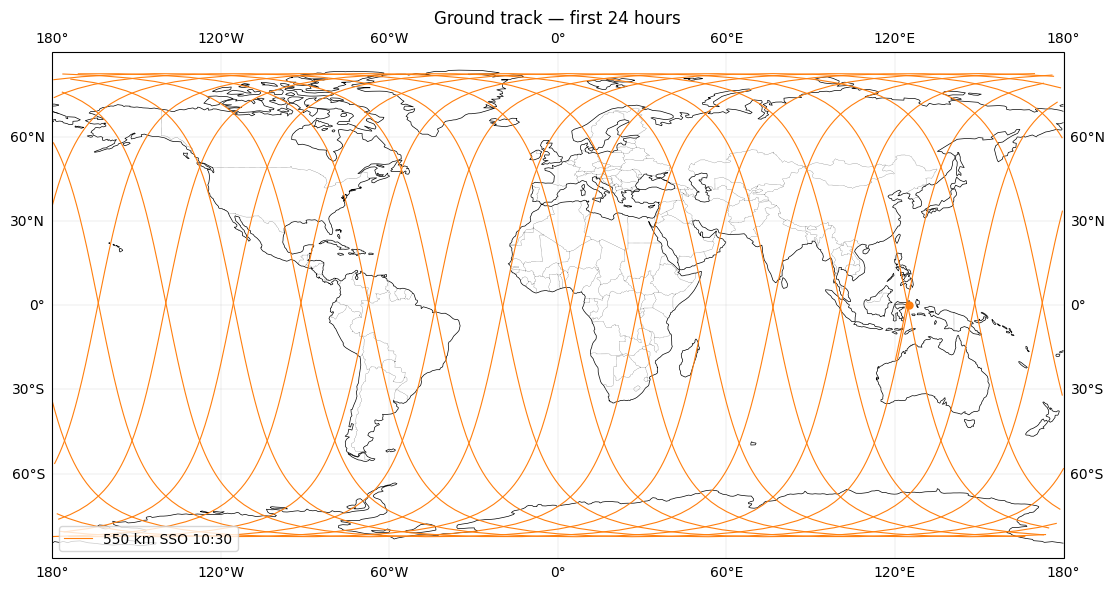

In [7]:
fig = plt.figure(figsize=(14, 6))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

plot_ground_track(
    sc,
    T_START,
    T_START + np.timedelta64(24 * 3600, 's'),
    ax=ax,
    color='tab:orange',
    label='550 km SSO 10:30',
    linewidth=0.8,
)
ax.set_title('Ground track — first 24 hours')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 7. Coverage maps over Canada

We use a Lambert Conformal Conic projection with the same geometric parameters
as EPSG:3347 (Statistics Canada Lambert).  We define it manually because
Cartopy's `ccrs.epsg(3347)` carries restrictive area-of-use bounds from the
EPSG registry that clip southern Canada out of the renderable area.

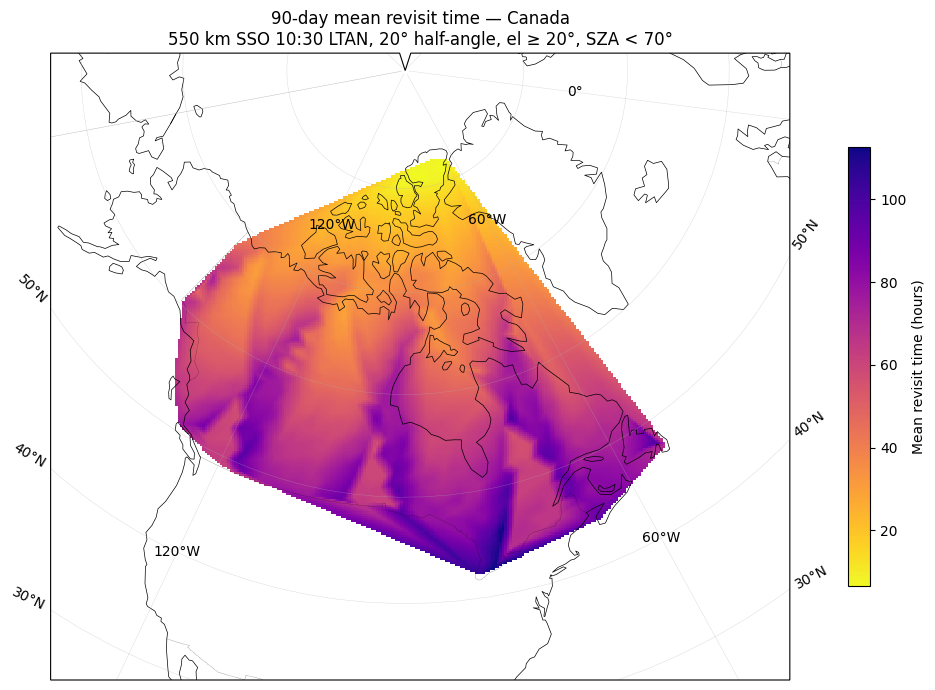

In [8]:
# Statistics Canada Lambert — same geometry as EPSG:3347 but without
# the restrictive area-of-use bounds that clip southern Canada.
canada_proj = ccrs.LambertConformal(
    central_longitude=-91.867,
    central_latitude=63.391,
    standard_parallels=(49, 77),
)

# --- Mean revisit time (hours) -------------------------------------------
mean_rev_hrs = rev['mean_revisit'] / 3600.0  # seconds → hours

fig, ax = plt.subplots(
    figsize=(12, 7),
    subplot_kw={'projection': canada_proj},
)
plot_coverage_map(
    aoi,
    mean_rev_hrs,
    ax=ax,
    auto_window=True,
    cmap='plasma_r',
    colorbar_label='Mean revisit time (hours)',
    title='90-day mean revisit time — Canada\n550 km SSO 10:30 LTAN, 20° half-angle, el ≥ 20°, SZA < 70°',
)
plt.tight_layout()
plt.show()

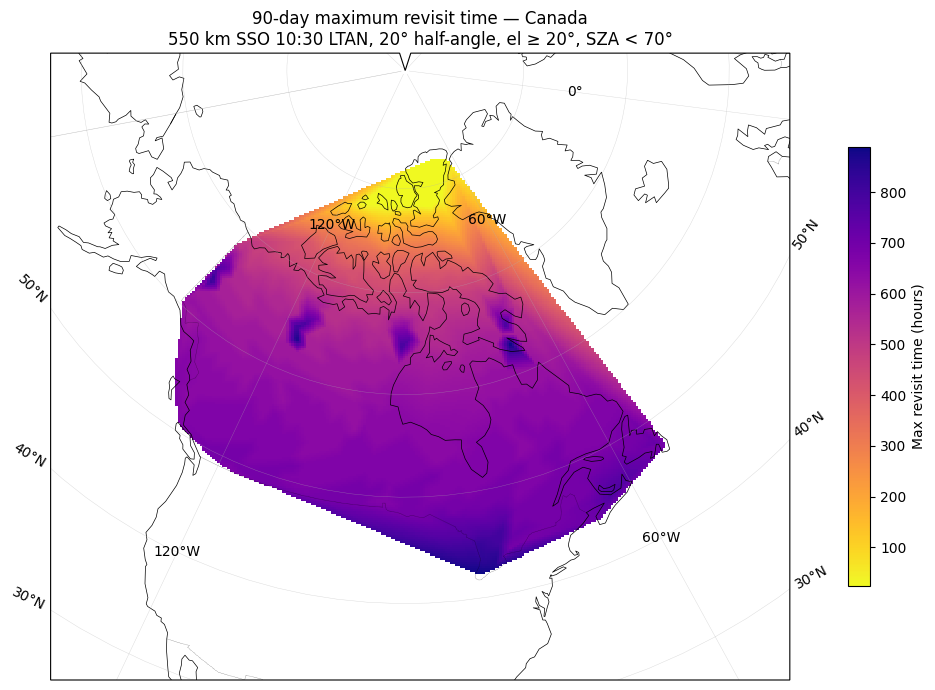

In [9]:
# --- Maximum revisit time (hours) -----------------------------------------
max_rev_hrs = rev['max_revisit'] / 3600.0  # seconds → hours

fig, ax = plt.subplots(
    figsize=(12, 7),
    subplot_kw={'projection': canada_proj},
)
plot_coverage_map(
    aoi,
    max_rev_hrs,
    ax=ax,
    auto_window=True,
    cmap='plasma_r',
    colorbar_label='Max revisit time (hours)',
    title='90-day maximum revisit time — Canada\n550 km SSO 10:30 LTAN, 20° half-angle, el ≥ 20°, SZA < 70°',
)
plt.tight_layout()
plt.show()

## 8. Summary statistics

In [10]:
print("=" * 50)
print("90-day coverage summary — Canada")
print("=" * 50)
print(f"Cumulative coverage fraction : {frac['final_cumulative']:.1%}")
print(f"Mean instantaneous coverage  : {frac['mean_fraction']:.1%}")
print()
global_mean_hrs = rev['global_mean'] / 3600.0
global_max_hrs  = rev['global_max']  / 3600.0
print(f"Global mean revisit time     : {global_mean_hrs:.1f} h")
print(f"Global max revisit time      : {global_max_hrs:.1f} h")

90-day coverage summary — Canada
Cumulative coverage fraction : 100.0%
Mean instantaneous coverage  : 0.0%

Global mean revisit time     : 60.1 h
Global max revisit time      : 893.9 h
